In [3]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel
import boto3
from google.cloud import storage
import torch

model_storage_folder = 'downloaded_models'

bucket_name = 'downloaded_llms'
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-chat-hf", "openai-community_gpt2", "facebook_opt-2.7b", "facebook_opt-125m"]



In [1]:
def load_model_from_path(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    model_files = [blob.name for blob in blobs if not blob.name.endswith('/')]
    return AutoModel.from_pretrained(model_files)

In [2]:
def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    os.makedirs(local_path, exist_ok=True)

    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path): 
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")


def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path


In [4]:
import shutil

def count_layers(model):
    layer_names = ['BertLayer', 'GPT2Block', 'T5Block', 'EncoderLayer', 'DecoderLayer', 'TransformerBlock']
    num_hidden_layers = 0
    for _, module in model.named_modules():
        if any(layer_name in module.__class__.__name__ for layer_name in layer_names):
            num_hidden_layers += 1

    return num_hidden_layers

def get_model_size(model_name, bucket_name):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/"
    blobs = bucket.list_blobs(prefix=prefix)
    total_size = sum(blob.size for blob in blobs)
    return total_size / (1024 * 1024)


def analyze_model_parameters(model):
    try:
        model_params = {name: param for name, param in model.named_parameters()}
        all_params = np.concatenate([p.data.cpu().numpy().flatten() for p in model_params.values()])
        
        stats = {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'total_layers': len(list(model.parameters())),
            'min': np.min(all_params),
            'max': np.max(all_params),
            'percent_within_1_std': np.mean((all_params >= -1) & (all_params <= 1)) * 100
        }
        return stats
    except Exception as e:
        print(f"Error during analysis: {e}")
        return {'error': str(e)}
    finally:
        gc.collect()

def analyze_model_stats(model, model_name, bucket_name):
    try:
        param_stats= analyze_model_parameters(model)
        num_hidden_layers = count_layers(model)
        model_size_mb = get_model_size(model_name, bucket_name)
        
        stats = {
            'model_size_mb': model_size_mb,
            'num_hidden_layers': num_hidden_layers,
            **param_stats
        }
        return stats
    except Exception as e:
        print(f"Error during analysis of {model_name}: {e}")
        return {'error': str(e)} 

def cleanup_model_directory(local_path):
    shutil.rmtree(local_path)
    print(f"Deleted model files at {local_path}")
    
def update_histogram_incrementally(model, bin_edges, bin_counts):
    for param in model.parameters():
        flat_param = param.data.cpu().numpy().flatten()
        counts, _ = np.histogram(flat_param, bins=bin_edges)
        bin_counts += counts
    return bin_counts

def analyze_model_data_types(model):
    data_types_stats = {}
    total_size_bytes = 0

    for param in model.parameters():
        param_size_bytes = param.data.element_size() * param.data.nelement()
        total_size_bytes += param_size_bytes
        data_type = str(param.dtype)

        if data_type not in data_types_stats:
            data_types_stats[data_type] = {'count': 0, 'total_size_bytes': 0, 'total_elements': 0}
        
        data_types_stats[data_type]['count'] += 1
        data_types_stats[data_type]['total_size_bytes'] += param_size_bytes
        data_types_stats[data_type]['total_elements'] += param.data.nelement()

    for data_type, stats in data_types_stats.items():
        stats['total_size_gb'] = stats['total_size_bytes'] / (1024**3)
        stats['percent_total_size'] = (stats['total_size_bytes'] / total_size_bytes) * 100
        stats['avg_elements'] = stats['total_elements'] / stats['count']
        stats['avg_size_mb'] = (stats['total_size_bytes'] / (1024**2)) / stats['count']

    return data_types_stats

In [5]:
# main workflow
def collect_model_stats(model_list, bucket_name, bin_edges):
    bin_counts = np.zeros(len(bin_edges) - 1, dtype=int)
    model_stats = []
    all_data_types_stats = []
    for model_name in model_list:
        print(f"Starting model analysis for {model_name}...")
        
        model, local_path = load_model_from_path(model_name, bucket_name)
        stats = analyze_model_stats(model, model_name, bucket_name)
        stats['model_name'] = model_name
        model_stats.append(stats)
        
        bin_counts = update_histogram_incrementally(model, bin_edges, bin_counts)
        
        data_types_stats = analyze_model_data_types(model)
        all_data_types_stats.append({'model_name': model_name, 'data_types_stats': data_types_stats})
        
        cleanup_model_directory(local_path)
        gc.collect()
        
        print(f"Completed model analysis for {model_name}.")
    
    data_list = [
        {
            'Layer Type': dtype,
            'Count': stats['count'],
            'Total Sz in GB': f"{stats['total_size_gb']:.2f} ({stats['percent_total_size']:.2f}%)",
            'Avg Para #': int(stats['avg_elements']),
            'Avg Sz in MB': f"{stats['avg_size_mb']:.2f}"
        }
        for model_stat in all_data_types_stats
        for dtype, stats in model_stat['data_types_stats'].items()
    ]
    df_stats = pd.DataFrame(data_list)
    return pd.DataFrame(model_stats), bin_counts, df_stats


In [7]:
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-chat-hf", "openai-community_gpt2", "facebook_opt-2.7b", "facebook_opt-125m"]

bin_edges = np.linspace(-3, 3, num=30)
model_statistics, bin_counts, df_stats = collect_model_stats(model_list, bucket_name, bin_edges)


Starting model analysis for google_gemma-2b-it...
Downloaded google_gemma-2b-it/config.json to ./google_gemma-2b-it/config.json.
Downloaded google_gemma-2b-it/pytorch_model.bin to ./google_gemma-2b-it/pytorch_model.bin.


/opt/conda/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Deleted model files at ./google_gemma-2b-it
Completed model analysis for google_gemma-2b-it.
Starting model analysis for meta-llama_Llama-2-7b-chat-hf...
Downloaded meta-llama_Llama-2-7b-chat-hf/config.json to ./meta-llama_Llama-2-7b-chat-hf/config.json.
Downloaded meta-llama_Llama-2-7b-chat-hf/pytorch_model.bin to ./meta-llama_Llama-2-7b-chat-hf/pytorch_model.bin.
Deleted model files at ./meta-llama_Llama-2-7b-chat-hf
Completed model analysis for meta-llama_Llama-2-7b-chat-hf.
Starting model analysis for openai-community_gpt2...
Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.
Deleted model files at ./openai-community_gpt2
Completed model analysis for openai-community_gpt2.
Starting model analysis for facebook_opt-2.7b...
Downloaded facebook_opt-2.7b/config.json to ./facebook_opt-2.7b/config.json.
Downloaded facebook_opt-2.7b/pytorch_model.bin to ./faceb

In [19]:
print(model_statistics)

   model_size_mb  num_hidden_layers  total_parameters        min        max  \
0    9560.352129                 18        2506172416  -9.750000  14.312500   
1   25205.144488                 32        6607343616  -1.414062   2.843750   
2     474.749109                 12         124439808 -11.050447  17.419317   
3   10115.219238                 32        2651596800  -0.500000   1.000000   
4     477.817388                 12         125239296  -1.231445   1.560547   

   percent_within_1_std                     model_name  total_layers  
0             99.947758             google_gemma-2b-it           164  
1             99.999937  meta-llama_Llama-2-7b-chat-hf           290  
2             99.988236          openai-community_gpt2           148  
3            100.000000              facebook_opt-2.7b           516  
4             99.999347              facebook_opt-125m           196  


In [9]:
print(df_stats)

      Layer Type  Count   Total Sz in GB  Avg Para # Avg Sz in MB
0  torch.float32    164   9.34 (100.00%)    15281539        58.29
1  torch.float32    290  24.61 (100.00%)    22783943        86.91
2  torch.float32    148   0.46 (100.00%)      840809         3.21
3  torch.float32    516   9.88 (100.00%)     5138753        19.60
4  torch.float32    196   0.47 (100.00%)      638976         2.44


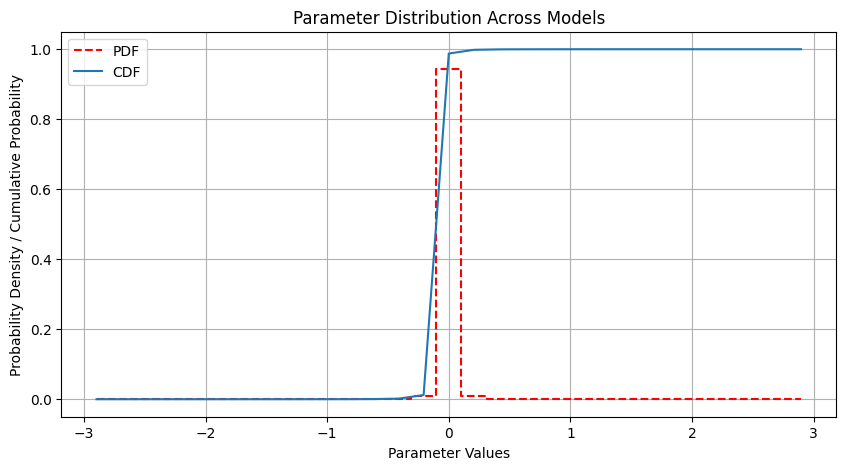

In [10]:
pdf = bin_counts / (np.sum(bin_counts) * np.diff(bin_edges)) / 5
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

cdf = np.cumsum(pdf * np.diff(bin_edges)) * 5


plt.figure(figsize=(10, 5))
plt.plot(bin_centers, pdf, drawstyle='steps-mid', linestyle='--', color='red', label='PDF')
plt.plot(bin_centers, cdf, label='CDF')
plt.xlabel('Parameter Values')
plt.ylabel('Probability Density / Cumulative Probability')
plt.title('Parameter Distribution Across Models')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [11]:
def calculate_cdf(data):
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / float(len(data_sorted))
    return data_sorted, cdf

size_sorted, size_cdf = calculate_cdf(model_statistics['model_size_mb'])
params_sorted, params_cdf = calculate_cdf(model_statistics['total_parameters'])
layers_sorted, layers_cdf = calculate_cdf(model_statistics['num_hidden_layers'])

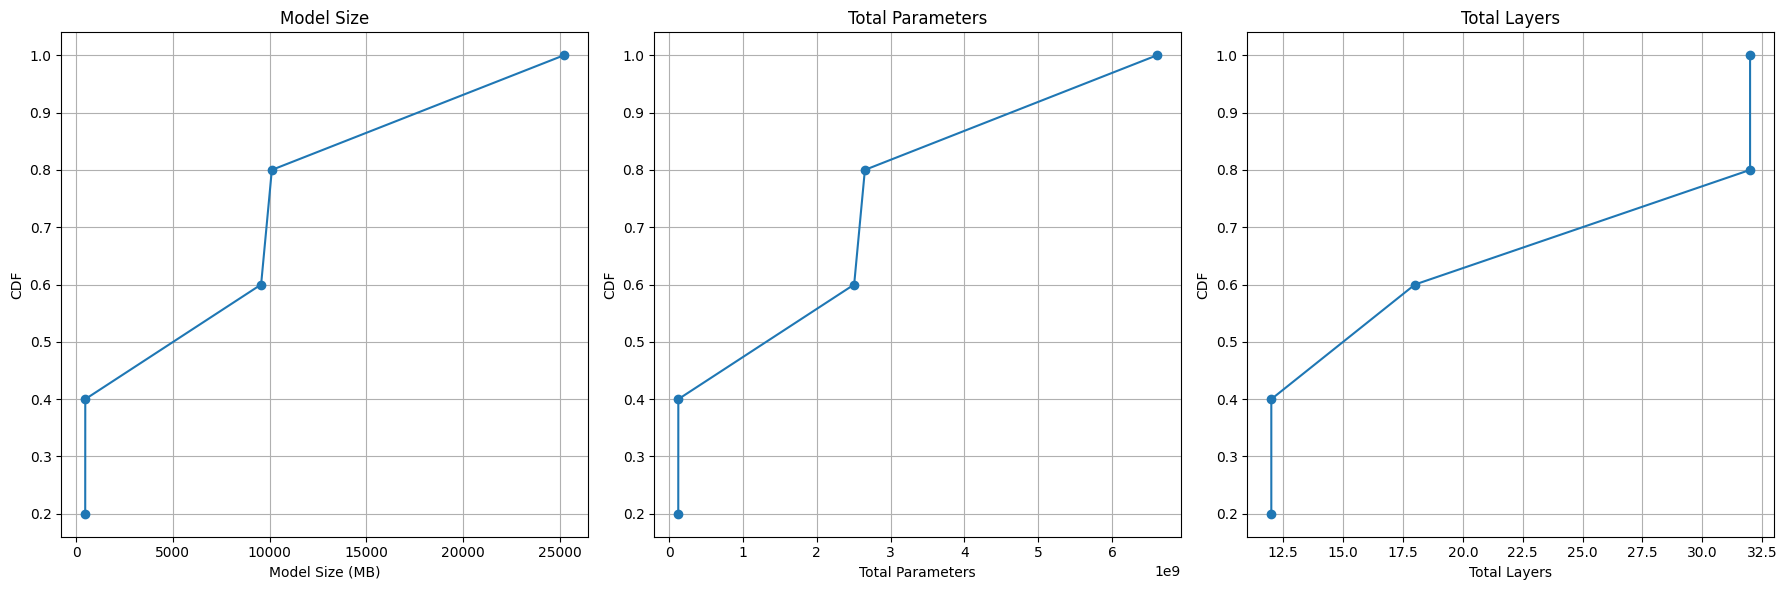

In [12]:
plt.figure(figsize=(18, 6))

# model size in MB
plt.subplot(1, 3, 1)
plt.plot(size_sorted, size_cdf, marker='o')
plt.xlabel('Model Size (MB)')
plt.ylabel('CDF')
plt.title('Model Size')
plt.grid(True)

# number of parameters
plt.subplot(1, 3, 2)
plt.plot(params_sorted, params_cdf, marker='o')
plt.xlabel('Total Parameters')
plt.ylabel('CDF')
plt.title('Total Parameters')
plt.grid(True)

# layer count
plt.subplot(1, 3, 3)
plt.plot(layers_sorted, layers_cdf, marker='o')
plt.xlabel('Total Layers')
plt.ylabel('CDF')
plt.title('Total Layers')
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
import transformers
print(transformers.__version__)


4.40.2


In [2]:
import os
import torch
import math
from collections import Counter, defaultdict
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def analyze_exponents_and_mantissas(model):
    exponent_counts = Counter()
    mantissa_counts = defaultdict(int)
    total_params = sum(p.numel() for p in model.parameters() if p.dtype in [torch.float32, torch.float16])
    pbar = tqdm(total=total_params, desc="Analyzing exponent and mantissa")
    for param in model.parameters():
        for data in param.data.flatten():
            mantissa, exponent = math.frexp(data.item())
            exponent_bin = f"{exponent + 1023:011b}" 
            mantissa_bin = f"{int((mantissa * 2) * (2**52)):052b}" if mantissa != 0 else '0' * 52
            exponent_counts[exponent_bin] += 1
            mantissa_counts[mantissa_bin] += 1
            pbar.update(1)
    pbar.close()

    return exponent_counts, mantissa_counts

def print_distribution(counts, description):
    total_counts = sum(counts.values())
    print(f"\nDistribution of {description}:")
    cnt = 0
    for key, count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        percentage = (count / total_counts) * 100
        print(f"{key}: {percentage:.2f}% ({count} times)")
        cnt += 1
        if cnt == 50:
            break

def cleanup_directory(path):
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
    os.rmdir(path)

In [3]:

model_list = ["facebook_opt-125m"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    exponent_counts, mantissa_counts = analyze_exponents_and_mantissas(model)
    print_distribution(exponent_counts, 'Exponents in Binary')
    print_distribution(mantissa_counts, 'Mantissas in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")


Starting analysis for facebook_opt-125m...

Distribution of Exponents in Binary:
01111111010: 24.20% (30309193 times)
01111111011: 23.23% (29090834 times)
01111111001: 17.07% (21382406 times)
01111111100: 12.63% (15821842 times)
01111111000: 10.00% (12520906 times)
01111110111: 5.34% (6691239 times)
01111110110: 2.75% (3448384 times)
01111111101: 1.89% (2361437 times)
01111110101: 1.40% (1754677 times)
01111110100: 0.71% (885923 times)
01111110011: 0.35% (444330 times)
01111110010: 0.18% (221525 times)
01111110001: 0.09% (110799 times)
01111111110: 0.06% (73663 times)
01111110000: 0.04% (55522 times)
01111101111: 0.02% (27995 times)
01111101110: 0.01% (14073 times)
01111111111: 0.01% (9225 times)
01111101101: 0.01% (7009 times)
01111101100: 0.00% (3473 times)
01111101011: 0.00% (1746 times)
10000000000: 0.00% (1557 times)
01111101010: 0.00% (887 times)
01111101001: 0.00% (441 times)
01111101000: 0.00% (210 times)

Distribution of Mantissas in Binary:
10000000001000000000000000000000000

In [5]:
model_list = ["openai-community_gpt2"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    exponent_counts, mantissa_counts = analyze_exponents_and_mantissas(model)
    print_distribution(exponent_counts, 'Exponents in Binary')
    print_distribution(mantissa_counts, 'Mantissas in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for openai-community_gpt2...
Downloaded openai-community_gpt2/config.json to ./openai-community_gpt2/config.json.
Downloaded openai-community_gpt2/pytorch_model.bin to ./openai-community_gpt2/pytorch_model.bin.

Distribution of Exponents in Binary:
01111111100: 28.39% (35331519 times)
01111111101: 24.99% (31092262 times)
01111111011: 18.71% (23277216 times)
01111111010: 10.24% (12740393 times)
01111111110: 6.18% (7693754 times)
01111111001: 5.33% (6631103 times)
01111111000: 2.81% (3500716 times)
01111110111: 1.51% (1883309 times)
01111110110: 0.79% (981770 times)
01111110101: 0.40% (498074 times)
01111111111: 0.24% (294684 times)
01111110100: 0.20% (250298 times)
01111110011: 0.10% (125657 times)
01111110010: 0.05% (62190 times)
01111110001: 0.03% (31170 times)
01111110000: 0.01% (15386 times)
10000000000: 0.01% (13194 times)
01111101111: 0.01% (7834 times)
01111101110: 0.00% (3848 times)
01111101101: 0.00% (1976 times)
10000000001: 0.00% (1251 times)
01111101100: 0.

In [ ]:
model_list = ["google_gemma-2b-it"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    exponent_counts, mantissa_counts = analyze_exponents_and_mantissas(model)
    print_distribution(exponent_counts, 'Exponents in Binary')
    print_distribution(mantissa_counts, 'Mantissas in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for google_gemma-2b-it...


Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.

Analyzing exponent and mantissa:   0%|          | 0/2506172416 [00:00<?, ?it/s]

In [23]:
import os
import torch
import math
from collections import Counter, defaultdict
from google.cloud import storage
from transformers import AutoModel
from pathlib import Path
from tqdm import tqdm

def download_files(model_name, bucket_name, local_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    prefix = f"{model_name}/" 
    blobs = bucket.list_blobs(prefix=prefix)
    
    Path(local_path).mkdir(parents=True, exist_ok=True)
    for blob in blobs:
        local_file_path = os.path.join(local_path, os.path.basename(blob.name))
        if not os.path.exists(local_file_path):
            blob.download_to_filename(local_file_path)
            print(f"Downloaded {blob.name} to {local_file_path}.")

def load_model_from_path(model_name, bucket_name):
    local_path = f"./{model_name}"
    download_files(model_name, bucket_name, local_path)
    model = AutoModel.from_pretrained(local_path)
    return model, local_path

def analyze_byte_by_byte(model):
    byte_counts = Counter()

    total_params = sum(p.numel() for p in model.parameters() if p.dtype in [torch.float32, torch.float16])
    pbar = tqdm(total=total_params, desc="Analyzing bytes")

    for param in model.parameters():
        param_data = param.data.cpu().numpy() 

        for data in param_data.flatten():
            weight_bytes = data.tobytes()
            for b in weight_bytes:
                byte_counts[f'{b:02x}'] += 1
            pbar.update(1)

    pbar.close()
    return byte_counts

def print_distribution(counts, description, limit=50):
    total_counts = sum(counts.values())
    print(f"\nDistribution of {description}:")
    sorted_counts = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    for key, count in sorted_counts[:limit]:  
        percentage = (count / total_counts) * 100
        print(f"{key.upper()}: {percentage:.2f}% ({count} times)")


def cleanup_directory(path):
    for root, dirs, files in os.walk(path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
    os.rmdir(path)

In [24]:

model_list = ["facebook_opt-125m"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for facebook_opt-125m...


Analyzing bytes: 100%|██████████| 125239296/125239296 [06:50<00:00, 305002.35it/s]



Distribution of Bytes in Binary:
00: 28.31% (141812103 times)
3D: 5.62% (28136916 times)
3C: 5.40% (27065209 times)
BC: 5.11% (25580386 times)
BD: 3.54% (17726056 times)
80: 3.31% (16577015 times)
20: 3.24% (16225928 times)
40: 3.23% (16168645 times)
A0: 3.22% (16148584 times)
C0: 3.21% (16103330 times)
60: 3.20% (16023478 times)
E0: 3.19% (15958248 times)
3B: 2.02% (10107627 times)
BB: 2.01% (10062977 times)
BA: 0.62% (3087808 times)
3A: 0.61% (3078322 times)
3E: 0.45% (2254656 times)
B9: 0.23% (1155478 times)
39: 0.23% (1143751 times)
BE: 0.22% (1124110 times)
81: 0.16% (810919 times)
82: 0.15% (767526 times)
83: 0.15% (742307 times)
01: 0.15% (740519 times)
84: 0.14% (720162 times)
02: 0.14% (711284 times)
85: 0.14% (706582 times)
86: 0.14% (695284 times)
03: 0.14% (695187 times)
04: 0.14% (683136 times)
87: 0.14% (683035 times)
88: 0.14% (676632 times)
05: 0.13% (671116 times)
89: 0.13% (668306 times)
06: 0.13% (663901 times)
8A: 0.13% (662121 times)
B8: 0.13% (660050 times)
07: 0

In [25]:

model_list = ["openai-community_gpt2"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for openai-community_gpt2...


Analyzing bytes: 100%|██████████| 124439808/124439808 [06:53<00:00, 301143.79it/s]



Distribution of Bytes in Binary:
BD: 6.18% (30785469 times)
3D: 6.17% (30709826 times)
BE: 4.20% (20900980 times)
3E: 4.17% (20773099 times)
3C: 2.24% (11139938 times)
BC: 2.23% (11120051 times)
3B: 0.84% (4156541 times)
BB: 0.83% (4120052 times)
3A: 0.44% (2207681 times)
BA: 0.44% (2169190 times)
80: 0.35% (1735551 times)
83: 0.34% (1691328 times)
81: 0.34% (1688505 times)
82: 0.34% (1686010 times)
00: 0.34% (1676563 times)
01: 0.34% (1668253 times)
02: 0.33% (1663934 times)
39: 0.33% (1658537 times)
84: 0.33% (1658126 times)
03: 0.33% (1656064 times)
04: 0.33% (1653697 times)
05: 0.33% (1647016 times)
85: 0.33% (1644343 times)
06: 0.33% (1643281 times)
09: 0.33% (1641335 times)
07: 0.33% (1640716 times)
86: 0.33% (1639492 times)
08: 0.33% (1638970 times)
87: 0.33% (1636100 times)
88: 0.33% (1632621 times)
0A: 0.33% (1630765 times)
89: 0.33% (1629876 times)
0B: 0.33% (1625958 times)
B9: 0.33% (1618010 times)
0C: 0.32% (1617199 times)
0D: 0.32% (1616471 times)
8A: 0.32% (1614775 times

In [ ]:
model_list = ["google_gemma-2b-it"]
bucket_name = 'downloaded_llms'

for model_name in model_list:
    print(f"Starting analysis for {model_name}...")
    model, local_path = load_model_from_path(model_name, bucket_name)
    
    byte_counts = analyze_byte_by_byte(model)
    print_distribution(byte_counts, 'Bytes in Binary')
    
    cleanup_directory(local_path)
    print(f"Completed analysis and cleaned up {model_name}")

Starting analysis for google_gemma-2b-it...
Downloaded google_gemma-2b-it/config.json to ./google_gemma-2b-it/config.json.


Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Downloaded google_gemma-2b-it/pytorch_model.bin to ./google_gemma-2b-it/pytorch_model.bin.


Analyzing bytes: 100%|██████████| 2506172416/2506172416 [2:16:05<00:00, 306912.70it/s]  



Distribution of Bytes in Binary:
00: 50.11% (5023360134 times)
3B: 5.48% (549164315 times)
BB: 5.47% (548444178 times)
3C: 2.49% (249160843 times)
BC: 2.48% (248726451 times)
3A: 2.04% (204305355 times)
BA: 2.04% (204165609 times)
3D: 1.27% (127255386 times)
BD: 1.26% (125831818 times)
3E: 1.01% (101395189 times)
BE: 0.99% (99703065 times)
39: 0.60% (59889418 times)
B9: 0.60% (59870823 times)
38: 0.22% (22409743 times)
B8: 0.22% (22364972 times)
3F: 0.15% (14851332 times)
01: 0.15% (14592080 times)
BF: 0.15% (14571870 times)
02: 0.14% (14472379 times)
03: 0.14% (14374025 times)
04: 0.14% (14261532 times)
05: 0.14% (14157666 times)
06: 0.14% (14047298 times)
07: 0.14% (13941272 times)
08: 0.14% (13836165 times)
09: 0.14% (13738674 times)
0A: 0.14% (13628626 times)
0B: 0.13% (13527333 times)
81: 0.13% (13428529 times)
0C: 0.13% (13425860 times)
0D: 0.13% (13320799 times)
82: 0.13% (13319772 times)
0E: 0.13% (13223069 times)
83: 0.13% (13220197 times)
0F: 0.13% (13134181 times)
84: 0.13%